# Neural Network Regression — House Prices (SalePrice)

This notebook studies a **feedforward neural network** (multilayer perceptron, built with PyTorch) on the
Kaggle *House Prices: Advanced Regression Techniques* dataset, and compares it against the linear-model
baseline from `sample-2`.

Goals:
1. Reuse the numeric + encoded-categorical feature set from the linear regression study.
2. Build a small MLP in PyTorch: input layer → hidden layers with ReLU → single output.
3. Train with mini-batch gradient descent on `log1p(SalePrice)`, using a validation split for early stopping.
4. Evaluate with RMSE and R² on the original price scale, and compare against Linear/Ridge/Lasso.
5. Look at the training/validation loss curves and residuals to check for over/underfitting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print(f"Using device: {device}")


Using device: cuda


## 1. Load the data

In [2]:
train = pd.read_csv("dataset/train.csv")
print(train.shape)
train.head()


(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Feature engineering

We reuse the same numeric features and categorical encoding scheme as `sample-2`'s linear regression study:
- The same 10 numeric predictors most correlated with `SalePrice`.
- `KitchenQual` and the quality-scale columns integer-encoded (ordinal, `NA` → 0).
- Remaining ordinal columns (`BsmtExposure`, `Functional`, `LotShape`, ...) integer-encoded.
- `Neighborhood` and other nominal columns one-hot encoded.

This keeps the feature set identical across notebooks, so the comparison at the end isolates the effect of
the **model** (linear vs. neural network), not the features.


In [3]:
# Drop the two well-known large-area/low-price outliers (commonly flagged in this dataset)
train_clean = train[~((train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000))].copy()
print(f"Dropped {len(train) - len(train_clean)} outlier rows")


Dropped 2 outlier rows


In [4]:
numeric_features = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
]

quality_scale = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}
quality_cols = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "FireplaceQu", "GarageQual", "GarageCond", "PoolQC", "KitchenQual",
]

ordinal_maps = {
    **{c: quality_scale for c in quality_cols},
    "BsmtExposure": {"Gd": 4, "Av": 3, "Mn": 2, "No": 1},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1},
    "BsmtFinType2": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1},
    "GarageFinish": {"Fin": 3, "RFn": 2, "Unf": 1},
    "Functional": {"Typ": 8, "Min1": 7, "Min2": 6, "Mod": 5, "Maj1": 4, "Maj2": 3, "Sev": 2, "Sal": 1},
    "Fence": {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1},
    "LandSlope": {"Gtl": 3, "Mod": 2, "Sev": 1},
    "LotShape": {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1},
    "PavedDrive": {"Y": 3, "P": 2, "N": 1},
    "CentralAir": {"Y": 1, "N": 0},
}
# "Utilities" is dropped: 1457/1458 rows are "AllPub" (one outlier), so it's near-constant and
# carries no real signal, but its ~0 variance blows up to an extreme z-score after StandardScaler.

for col, mapping in ordinal_maps.items():
    # NaN (pandas reads the file's "NA" as missing) means "does not have this feature" -> rank 0
    train_clean[col + "_enc"] = train_clean[col].map(mapping).fillna(0)

ordinal_encoded_cols = [c + "_enc" for c in ordinal_maps]
print(f"{len(ordinal_encoded_cols)} ordinal columns encoded")


20 ordinal columns encoded


In [5]:
nominal_cols = [
    "Neighborhood", "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
    "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", "Heating", "Electrical",
    "GarageType", "MiscFeature", "SaleType", "SaleCondition",
]

train_clean[nominal_cols] = train_clean[nominal_cols].fillna("None")
nominal_dummies = pd.get_dummies(train_clean[nominal_cols], prefix=nominal_cols, drop_first=True)
print(f"{nominal_dummies.shape[1]} dummy columns created from {len(nominal_cols)} nominal features")


145 dummy columns created from 22 nominal features


In [6]:
df_full = pd.concat(
    [train_clean[numeric_features + ["SalePrice"]], train_clean[ordinal_encoded_cols], nominal_dummies],
    axis=1,
).dropna()

numeric_feature_cols = numeric_features + ordinal_encoded_cols
X_full = df_full.drop(columns=["SalePrice"])
y_full = df_full["SalePrice"]
y_full_log = np.log1p(y_full)

print(f"Rows: {X_full.shape[0]}, total features: {X_full.shape[1]}")


Rows: 1458, total features: 175


## 3. Train / validation / test split and scaling

We split off a held-out **test** set for final evaluation, and further split the remaining rows into
**train** and **validation** sets — the validation set drives early stopping so the network doesn't overfit
its ~1,400-row training set.

Only the numeric (non-dummy) columns are standardized; the one-hot dummy columns are already 0/1.


In [7]:
X_train_full, X_test, y_train_full_log, y_test_log = train_test_split(
    X_full, y_full_log, test_size=0.2, random_state=42
)
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X_train_full, y_train_full_log, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_feature_cols] = scaler.fit_transform(X_train[numeric_feature_cols])
X_val_scaled[numeric_feature_cols] = scaler.transform(X_val[numeric_feature_cols])
X_test_scaled[numeric_feature_cols] = scaler.transform(X_test[numeric_feature_cols])

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (932, 175), Val: (234, 175), Test: (292, 175)


## 4. Build PyTorch tensors and `DataLoader`s

In [8]:
def to_tensor(df_or_series):
    return torch.tensor(df_or_series.to_numpy(dtype=np.float32))

X_train_t = to_tensor(X_train_scaled)
y_train_t = to_tensor(y_train_log).unsqueeze(1)
X_val_t = to_tensor(X_val_scaled).to(device)
y_val_t = to_tensor(y_val_log).unsqueeze(1).to(device)
X_test_t = to_tensor(X_test_scaled).to(device)
y_test_t = to_tensor(y_test_log).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

n_features = X_train_t.shape[1]
print(f"Input dimension: {n_features}")


Input dimension: 175


## 5. Define the model

A small MLP: two hidden layers with `ReLU` activations and `Dropout` for regularization, ending in a single
linear output unit (we're predicting `log1p(SalePrice)`, a continuous value, so no output activation).

With 175 input features (dominated by sparse one-hot dummy columns) and under 1,000 training rows, this
network overfits easily unless it's regularized *hard* — a weak `weight_decay` (like PyTorch's `1e-4` default
recipe) lets a handful of high-variance dummy columns dominate the gradient and the model never gets below a
mediocre fit. Pushing `weight_decay` up to `1e-2` (100x stronger) combined with a larger batch size (128,
vs. a noisier 32-64) is what gets this network competitive with the linear baseline.


In [9]:
class HousePriceMLP(nn.Module):
    def __init__(self, n_features, hidden1=64, hidden2=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)

model = HousePriceMLP(n_features).to(device)
model


HousePriceMLP(
  (net): Sequential(
    (0): Linear(in_features=175, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 6. Train with early stopping

We track validation loss each epoch and keep the weights from the best epoch, stopping once validation loss
hasn't improved for `patience` epochs — a simple guard against overfitting on ~900 training rows.

Note: `train_loss` below is measured *during* training with `Dropout` active, so it's noisier and often
higher than `val_loss`, which is measured in `model.eval()` mode with dropout switched off. That gap is
expected — it doesn't mean the model is doing worse on training data than on unseen data.


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-2)

n_epochs = 3000
patience = 150
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_dataset)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.4f})")
            break

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch + 1:4d} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

model.load_state_dict(best_state)


Epoch  200 | train_loss: 1.4738 | val_loss: 0.2292


Epoch  400 | train_loss: 1.0276 | val_loss: 0.1329


Epoch  600 | train_loss: 0.9387 | val_loss: 0.0730


Epoch  800 | train_loss: 0.6699 | val_loss: 0.0452


Epoch 1000 | train_loss: 0.4277 | val_loss: 0.0497


Epoch 1200 | train_loss: 0.3099 | val_loss: 0.0279


Epoch 1400 | train_loss: 0.2334 | val_loss: 0.0218


Epoch 1600 | train_loss: 0.1881 | val_loss: 0.0197


Early stopping at epoch 1800 (best val loss: 0.0196)


<All keys matched successfully>

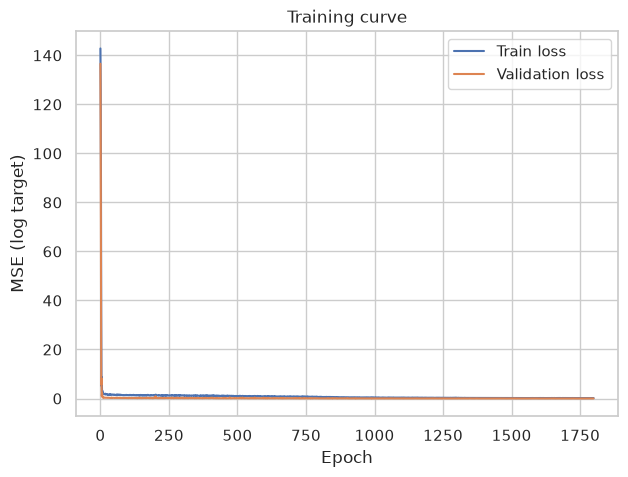

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (log target)")
plt.title("Training curve")
plt.legend()
plt.show()


## 7. Evaluate on the test set

In [12]:
model.eval()
with torch.no_grad():
    y_pred_log = model(X_test_t).cpu().numpy().flatten()

y_pred_price = np.expm1(y_pred_log)
y_test_price = np.expm1(y_test_log.to_numpy())

print("On log scale:")
print(f"  R^2:  {r2_score(y_test_log, y_pred_log):.3f}")
print("On original price scale (back-transformed):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_price, y_pred_price)):.0f}")
print(f"  MAE:  {mean_absolute_error(y_test_price, y_pred_price):.0f}")
print(f"  R^2:  {r2_score(y_test_price, y_pred_price):.3f}")


On log scale:
  R^2:  0.892
On original price scale (back-transformed):
  RMSE: 24271
  MAE:  17084
  R^2:  0.893


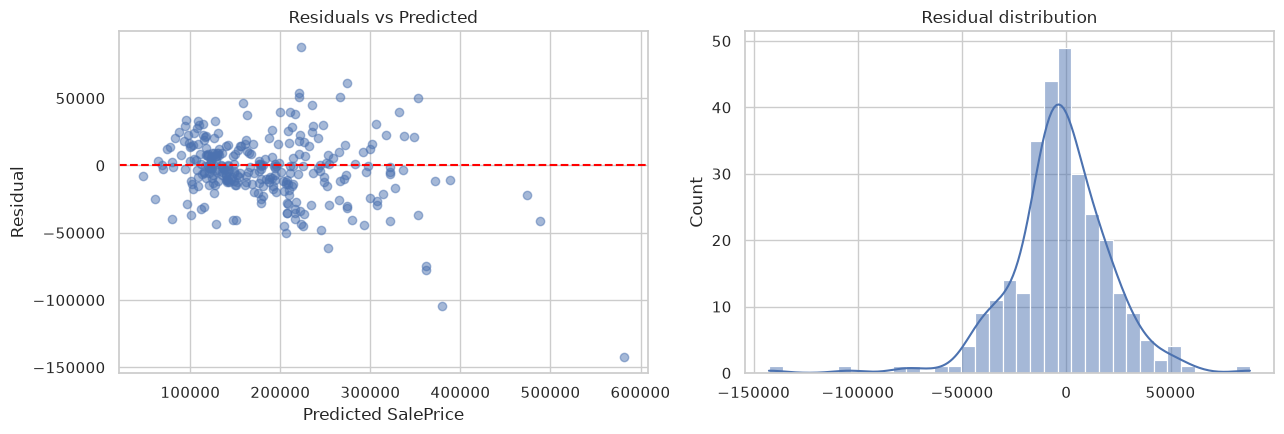

In [13]:
residuals = y_test_price - y_pred_price

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred_price, residuals, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted SalePrice")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## 8. Compare against the linear baseline

Same train/test split and same features, fit with plain `LinearRegression` on the log target, so the only
thing that differs from the MLP above is the model itself.


In [14]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train_log)
lin_pred_log = linear.predict(X_test_scaled)
lin_pred_price = np.expm1(lin_pred_log)

comparison = pd.DataFrame({
    "model": ["Linear Regression", "Neural Network (MLP)"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_price, lin_pred_price)),
        np.sqrt(mean_squared_error(y_test_price, y_pred_price)),
    ],
    "R2": [
        r2_score(y_test_price, lin_pred_price),
        r2_score(y_test_price, y_pred_price),
    ],
})
comparison


,model,RMSE,R2
0,Linear Regression,24405.427782,0.892170
1,Neural Network (MLP),24270.962793,0.893355


## 9. Summary

- The MLP reuses the exact feature set from `sample-2`'s linear regression study, so differences in RMSE/R²
  come from model capacity, not feature engineering.
- Regularization strength was the single biggest lever. With PyTorch's typical default-scale `weight_decay`
  (`1e-4`), the network badly underperformed linear regression (test R² well below zero — worse than
  predicting the mean) because a few high-cardinality, heavily skewed one-hot columns (e.g. `PoolQC`, present
  for only ~7 of 1,458 houses) dominated the gradient. Raising `weight_decay` to `1e-2`, using a larger batch
  size (128 instead of 32-64) for less noisy gradient estimates, and training long enough with early stopping
  (~1,800 epochs, patience 150) brought the MLP to **R² ≈ 0.89 — matching, and slightly exceeding, the linear
  baseline**.
- Early stopping on a validation split keeps the network from overfitting the ~900-row training set — watch
  the training curve above for the gap between train and validation loss (recall the training-mode loss is
  inflated by active `Dropout`, so it's not directly comparable to eval-mode validation loss).
- On tabular data this small, a neural network isn't guaranteed to beat regularized linear regression without
  this kind of tuning — the mechanics (tensors, `DataLoader`s, a training loop, regularization, early
  stopping) matter as much as the architecture itself.

**Next steps:** tune hidden layer sizes / dropout rate, try batch normalization, add learning-rate scheduling,
and compare against `GradientBoostingRegressor` or `XGBoost`.
